In [1]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt

freyja_barcodes_path = '../data/sars2_metadata/usher_barcodes.feather'

# Load Freyja barcodes
freyja_barcodes = pd.read_feather(freyja_barcodes_path)
barcode_muts = freyja_barcodes.columns.tolist()


matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


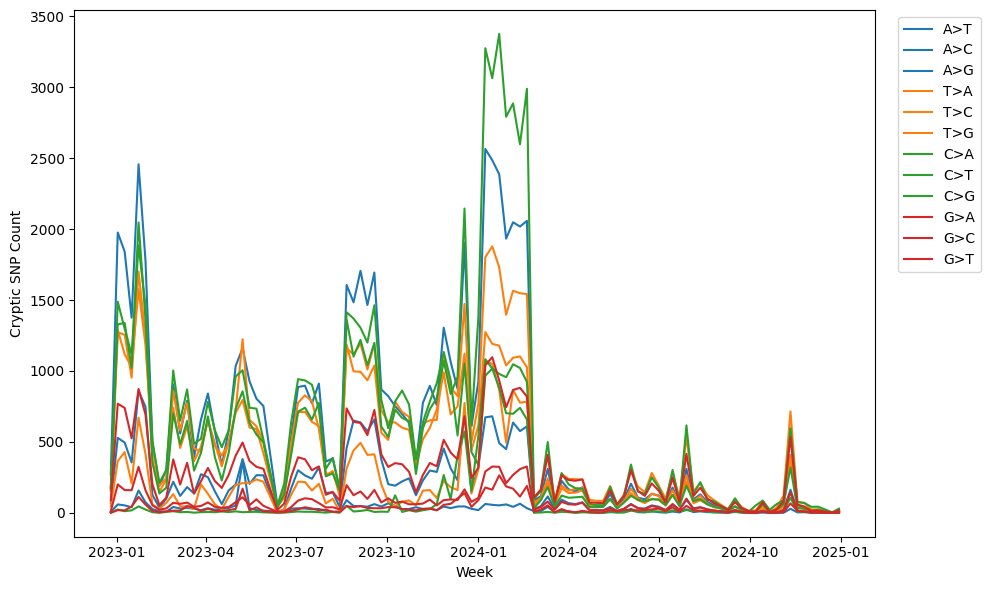

In [2]:
df = pd.read_csv('../data/covar_clinical_detections.tsv', sep='\t')
df['mutations_filtered'] = df['nt_mutations'].apply(lambda x: [mut for mut in x.split(' ')])# if mut not in barcode_muts])

df['collection_date'] = pd.to_datetime(df['collection_date'])
df['week'] = df['collection_date'].dt.to_period('W').dt.to_timestamp()

snp_types = [
    'A>T', 'A>C', 'A>G', 'T>A', 'T>C', 'T>G',
    'C>A', 'C>T', 'C>G', 'G>A', 'G>C', 'G>T',
]

# Compute SNP type counts per week
weekly_snp_counts = []
for _, row in df.iterrows():
    for mut in row['mutations_filtered']:
        if '+' in mut or '-' in mut:
            continue
        snp_type = f'{mut[0]}>{mut[-1]}'
        weekly_snp_counts.append({'week': row['week'], 'snp_type': snp_type})

weekly_df = pd.DataFrame(weekly_snp_counts)
# Get counts per week per SNP type
weekly_freqs = weekly_df.groupby(['week', 'snp_type']).size().unstack(fill_value=0)


for st in snp_types:
    if st not in weekly_freqs.columns:
        weekly_freqs[st] = 0
weekly_freqs = weekly_freqs[snp_types]

# save weekly_freqs
weekly_freqs.to_csv('non_cryptic_snp_freqs.csv')

color_map = {'A': '#1f77b4', 'T': '#ff7f0e', 'C': '#2ca02c', 'G': '#d62728'}
colors = [color_map[st[0]] for st in snp_types]


# plot weekly_freqs
plt.figure(figsize=(10, 6))
for st in snp_types:
    plt.plot(weekly_freqs.index, weekly_freqs[st], label=st, color=colors[snp_types.index(st)])
plt.xlabel('Week')
plt.ylabel('Cryptic SNP Count')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1)
plt.tight_layout()
plt.show()

